In [2]:
import torch
print(torch.cuda.is_available())   # should be True
print(torch.version.cuda)          # CUDA version PyTorch is built with
print(torch.cuda.get_device_name(0)) if torch.cuda.is_available() else None
print(torch.cuda.device_count())
import os
os.cpu_count()

True
11.7
NVIDIA RTX 6000 Ada Generation
2


48

In [6]:

from typing import Dict, Tuple, List, Optional
import numpy as np
import pandas as pd
import logging
logger = logging.getLogger(__name__)

def load_ap1_data_from_csv(csv_filepath: str, replicate: Optional[int] = None) -> Dict[str, np.ndarray]:
    """
    Loads AP1 single-cell data from CSV or Excel file.

    Args:
        csv_filepath: Path to the CSV or Excel file

    Returns:
        Dictionary with condition identifiers as keys and feature matrices as values
    """
    logger.info(f"Loading data from: {csv_filepath}")

    # Load the data based on file extension
    if csv_filepath.endswith('.csv'):
        df = pd.read_csv(csv_filepath)
    elif csv_filepath.endswith('.xlsx'):
        df = pd.read_excel(csv_filepath)
    else:
        raise ValueError("Unsupported file format. Please provide a .csv or .xlsx file.")
    
    replacement_map = {
                        '0.316 uM Vemurafenib': 'Vem',
                        '0.316 uM Vem + 0.0316 uM Tram': 'Vem+Tram'
                        }
    df['condition'] = df['condition'].replace(replacement_map)

    print(df['condition'].unique())

    # Define AP1 protein features (these are in log space already)
    ap1_features = [
        'cFOS (log a.u.)', 'p-cFOS (log a.u.)', 'FRA1 (log a.u.)', 'p-FRA1 (log a.u.)', 'FRA2 (log a.u.)',
        'cJUN (log a.u.)', 'p-cJUN (log a.u.)', 'JUNB (log a.u.)', 'JUND (log a.u.)', 'p-ATF1 (log a.u.)',
        'ATF2 (log a.u.)',	 'p-ATF2 (log a.u.)', 'ATF3 (log a.u.)', 'ATF4 (log a.u.)', 'p-ATF4 (log a.u.)',
        'ATF5 (log a.u.)', 'ATF6 (log a.u.)', 'MITF (log a.u.)', 'NGFR (log a.u.)', 'p-ERK (log a.u.)',
    ]

    # Check if all features exist
    missing_features = [f for f in ap1_features if f not in df.columns]
    if missing_features:
        logger.warning(f"Missing features: {missing_features}")
        ap1_features = [f for f in ap1_features if f in df.columns]

    logger.info(f"Using {len(ap1_features)} AP1 features")

    # Create condition-based data dictionary
    data_dict = {}

    if replicate is not None:
        # Group by condition, time, and cell line
        for (condition, time, cell_line, replicate_id), group in df.groupby(['condition', 'time', 'cell_line', 'replicate_id']):
            # Create condition identifier
            condition_id = f"{cell_line}_{condition}_{time.replace(' ', '')}_rep{replicate_id}"

            # Extract feature matrix
            feature_matrix = group[ap1_features].values

            # Remove rows with any NaN values
            valid_rows = ~np.isnan(feature_matrix).any(axis=1)
            feature_matrix = feature_matrix[valid_rows]

            if len(feature_matrix) > 0:
                data_dict[condition_id] = feature_matrix
                logger.info(f"Loaded {condition_id}: {feature_matrix.shape}")
            else:
                logger.warning(f"No valid data for {condition_id}")
    else:
        # Group by condition, time, and cell line
        for (condition, time, cell_line), group in df.groupby(['condition', 'time', 'cell_line']):
            # Create condition identifier
            condition_id = f"{cell_line}_{condition}_{time.replace(' ', '')}"

            # Extract feature matrix
            feature_matrix = group[ap1_features].values

            # Remove rows with any NaN values
            valid_rows = ~np.isnan(feature_matrix).any(axis=1)
            feature_matrix = feature_matrix[valid_rows]

            if len(feature_matrix) > 0:
                data_dict[condition_id] = feature_matrix
                logger.info(f"Loaded {condition_id}: {feature_matrix.shape}")
            else:
                logger.warning(f"No valid data for {condition_id}")

    return data_dict

def prepare_pair_from_mat(cell_line: str,
                          baseline_condition: str, baseline_time: str,
                          target_condition: str, target_time: str,
                          replicate: Optional[int] = None) -> Tuple[np.ndarray, np.ndarray]:
    print("Cell line: ", cell_line)
    raw_data_dict = load_ap1_data_from_csv('mmc5.xlsx', replicate)

    if replicate is not None:
        pre_key = f"{cell_line}_{baseline_condition}_{baseline_time}_rep{replicate}"
        post_key = f"{cell_line}_{target_condition}_{target_time}_rep{replicate}"
    else:
        pre_key = f"{cell_line}_{baseline_condition}_{baseline_time}"
        post_key = f"{cell_line}_{target_condition}_{target_time}"

    if pre_key not in raw_data_dict or post_key not in raw_data_dict:
        raise ValueError(f"Pair not found: {pre_key}, {post_key}")

    # Equalize N
    n = min(len(raw_data_dict[pre_key]), len(raw_data_dict[post_key]))
    X_pre_raw = raw_data_dict[pre_key][:n]
    X_post_raw = raw_data_dict[post_key][:n]
    return X_pre_raw, X_post_raw



In [7]:
import os
import sys
import json
import logging
import argparse
import geomloss
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm
import numpy as np
import pandas as pd
from pathlib import Path
from typing import Dict, Tuple, List, Optional
from umap import UMAP
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics.pairwise import rbf_kernel
from typing import Dict, Tuple, List
from scipy.stats import ks_2samp
from scipy.spatial.distance import cdist
from sklearn.metrics import r2_score

import gc
gc.collect()

def median_heuristic_gamma(X: np.ndarray, Y: np.ndarray) -> float:
    """
    Median heuristic for RBF bandwidth: gamma = 1 / median(||x - y||^2).
    Uses the median of pairwise distances in the pooled set.
    """
    Z = np.vstack([X, Y])
    # Sample if too large for efficiency
    max_samples = 5000
    if Z.shape[0] > max_samples:
        idx = np.random.choice(Z.shape[0], size=max_samples, replace=False)
        Z = Z[idx]
    D2 = cdist(Z, Z, metric='sqeuclidean')
    # Use upper triangular without diagonal
    triu = D2[np.triu_indices_from(D2, k=1)]
    med = np.median(triu[triu > 0]) if np.any(triu > 0) else 1.0
    return 1.0 / max(med, 1e-12)

def mmd_distance(X: np.ndarray, Y: np.ndarray, gamma: float) -> float:
    """
    Unbiased MMD^2 estimator using Gaussian (RBF) kernel, sklearn backend.

    Args:
        X: (n_samples, n_features) first sample
        Y: (m_samples, n_features) second sample
        gamma: RBF kernel bandwidth; if None, uses median heuristic

    Returns:
        Unbiased MMD^2 value
    """
    n = X.shape[0]
    m = Y.shape[0]

    # Kernel matrices
    Kxx = rbf_kernel(X, X, gamma=gamma)
    Kyy = rbf_kernel(Y, Y, gamma=gamma)
    Kxy = rbf_kernel(X, Y, gamma=gamma)

    # Unbiased: exclude diagonal entries
    np.fill_diagonal(Kxx, 0.0)
    np.fill_diagonal(Kyy, 0.0)

    term_xx = Kxx.sum() / (n * (n - 1)) if n > 1 else 0.0
    term_yy = Kyy.sum() / (m * (m - 1)) if m > 1 else 0.0
    term_xy = 2.0 * Kxy.mean()

    mmd2 = term_xx + term_yy - term_xy
    mmd2 = max(mmd2, 0.0)  # Numerical stability
    return float(mmd2)

def r2_feature_means(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """
    R^2 computed across features between mean vectors of y_true and y_pred.
    """
    mu_true = y_true.mean(axis=0)
    mu_pred = y_pred.mean(axis=0)
    ss_res = float(np.sum((mu_true - mu_pred) ** 2))
    ss_tot = float(np.sum((mu_true - mu_true.mean()) ** 2))
    if ss_tot <= 1e-12:
        return 1.0 if ss_res <= 1e-12 else 0.0
    return 1.0 - ss_res / ss_tot

def wasserstein_pointcloud(
    X,
    Y,
    p: int = 2,
    a=None,
    b=None,
    method: str = "emd",          # "emd" (exact) or "sinkhorn" (approx)
    reg: float = 1e-1,            # Sinkhorn regularization (only used if method="sinkhorn")
    return_plan: bool = False,
):
    """
    Compute Wasserstein distance W_p between two empirical distributions supported on point sets X and Y.

    Parameters
    ----------
    X : (n, d) array-like
        Source points.
    Y : (m, d) array-like
        Target points.
    p : int
        Order of the Wasserstein distance (commonly 1 or 2).
    a : (n,) array-like or None
        Weights for X; if None, uniform weights.
    b : (m,) array-like or None
        Weights for Y; if None, uniform weights.
    method : str
        "emd" for exact optimal transport (requires POT),
        "sinkhorn" for entropic approximation (requires POT).
    reg : float
        Entropic regularization strength for Sinkhorn.
    return_plan : bool
        If True, also return the optimal transport plan.

    Returns
    -------
    Wp : float
        Wasserstein distance of order p.
    plan : (n, m) ndarray, optional
        Optimal transport plan (only if return_plan=True).
    """
    X = np.asarray(X, dtype=np.float64)
    Y = np.asarray(Y, dtype=np.float64)
    if X.ndim != 2 or Y.ndim != 2:
        raise ValueError("X and Y must be 2D arrays with shape (n, d) and (m, d).")
    if X.shape[1] != Y.shape[1]:
        raise ValueError(f"Dimension mismatch: X has d={X.shape[1]}, Y has d={Y.shape[1]}.")

    n, d = X.shape
    m, _ = Y.shape

    if a is None:
        a = np.full(n, 1.0 / n, dtype=np.float64)
    else:
        a = np.asarray(a, dtype=np.float64)
        a = a / a.sum()

    if b is None:
        b = np.full(m, 1.0 / m, dtype=np.float64)
    else:
        b = np.asarray(b, dtype=np.float64)
        b = b / b.sum()

    # Cost matrix: C_ij = ||x_i - y_j||^p
    # Compute squared Euclidean via (x-y)^2 = x^2 + y^2 - 2xy for speed
    X2 = np.sum(X * X, axis=1, keepdims=True)          # (n, 1)
    Y2 = np.sum(Y * Y, axis=1, keepdims=True).T        # (1, m)
    sq = np.maximum(X2 + Y2 - 2.0 * (X @ Y.T), 0.0)     # (n, m)
    if p == 2:
        C = sq
    else:
        C = sq ** (p / 2.0)

    try:
        import ot  # POT: Python Optimal Transport
    except ImportError as e:
        raise ImportError(
            "This function requires the POT library. Install with: pip install pot"
        ) from e

    method = method.lower()
    if method == "emd":
        # exact OT: minimizes <P, C>
        P = ot.emd(a, b, C)
        cost = float(np.sum(P * C))
    elif method == "sinkhorn":
        # entropic OT approximation
        P = ot.sinkhorn(a, b, C, reg=reg)
        cost = float(np.sum(P * C))
    else:
        raise ValueError('method must be either "emd" or "sinkhorn".')

    Wp = cost ** (1.0 / p)

    if return_plan:
        return Wp, P
    return Wp

def summarize_metrics(y_true: np.ndarray, y_pred: np.ndarray, median_gamma: float) -> dict:
    """
    Compute a standard set of metrics: MMD^2 (RBF), R^2 of feature means, median KS across features, and Wasserstein distance.
    """
    # Drop any samples that contain NaNs in either true or pred
    mask = (~np.isnan(y_true).any(axis=1)) & (~np.isnan(y_pred).any(axis=1))
    if mask.sum() < len(y_true):
        print(f"[summarize_metrics] Dropping {len(y_true) - mask.sum()} samples with NaNs.")
    
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    out = {}

    out['mmd2_gamma_median'] = mmd_distance(y_true, y_pred, gamma=median_gamma)
    out['mmd2_gamma_0.5'] = mmd_distance(y_true, y_pred, gamma=0.5)
    out['mmd2_gamma_1.0'] = mmd_distance(y_true, y_pred, gamma=1.0)
    out['wasserstein_distance'] = wasserstein_pointcloud(y_true, y_pred, p=2, method="emd")
    out['R2_feature_means'] = r2_feature_means(y_true, y_pred)
    return out

def split_train_test(X: np.ndarray, Y: np.ndarray, train_fraction: float, seed: int = 42) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    if X.shape[0] != Y.shape[0]:
        min_len = min(len(X), len(Y))
        X = X[:min_len]
        Y = Y[:min_len]

    n = X.shape[0]
    n_train = max(1, int(n * train_fraction))
    rng = np.random.default_rng(seed)
    idx = rng.permutation(n)
    tr_idx, te_idx = idx[:n_train], idx[n_train:]
    return X[tr_idx], X[te_idx], Y[tr_idx], Y[te_idx]

def topk_markers(adata, drug: str, k: int = 50, rank_key: str = "marker_genes-drug-rank"):
    R = adata.varm[rank_key]

    # --- get the rank vector for this drug ---
    if hasattr(R, "columns") and hasattr(R, "iloc"):  # pandas DataFrame
        if drug in R.columns:
            r = R[drug].to_numpy()
        else:
            # fallback: interpret columns as ordered groups; try to map via rank_genes_groups names
            names = adata.uns["rank_genes_groups"]["names"]
            groups = list(names.dtype.names) if (hasattr(names, "dtype") and names.dtype.names is not None) else list(names.columns)
            r = R.iloc[:, groups.index(drug)].to_numpy()
    else:  # numpy array (or array-like)
        names = adata.uns["rank_genes_groups"]["names"]
        groups = list(names.dtype.names) if (hasattr(names, "dtype") and names.dtype.names is not None) else list(names.columns)
        r = np.asarray(R)[:, groups.index(drug)]

    # smaller rank => stronger marker
    idx = np.argsort(r)[:k]
    gene_ids = adata.var_names[idx].to_list()
    gene_short = (adata.var.iloc[idx]["gene_short_name"].to_list()
                  if "gene_short_name" in adata.var.columns else None)
    return gene_ids, gene_short, idx


In [8]:
import sys
import torch
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from cellot.models.cellot import load_networks, compute_loss_f, compute_loss_g

from sklearn.metrics.pairwise import rbf_kernel


def mmd_distance(x, y, gamma):
    xx = rbf_kernel(x, x, gamma)
    xy = rbf_kernel(x, y, gamma)
    yy = rbf_kernel(y, y, gamma)

    return xx.mean() + yy.mean() - 2 * xy.mean()

def compute_mmd_loss(lhs, rhs, gammas):
    return np.mean([mmd_distance(lhs, rhs, g) for g in gammas])

from cellot.losses.mmd import mmd_distance

def run_cellot_pair(train_pre: np.ndarray, train_post: np.ndarray,
                    test_pre: np.ndarray, test_post: np.ndarray,
                    layers: Optional[List[int]] = [32, 32 ,32],
                    n_epochs: int = 5000,
                    feature_subset: Optional[List[int]] = None,) -> Dict:
    
    device = 'cuda'
    print(f"VERS torch={torch.__version__} (CellOT), device={device}", file=sys.stderr, flush=True)


    # Apply feature subset if specified
    if feature_subset is not None:
        print(f"Using feature subset of size {len(feature_subset)}", file=sys.stderr, flush=True)
        train_pre = train_pre[:, feature_subset]
        train_post = train_post[:, feature_subset]
        test_pre = test_pre[:, feature_subset]
        test_post = test_post[:, feature_subset]

    # Preprocess: standardize jointly and optionally apply PCA for stability
    X_all = np.vstack([train_pre, train_post])
    scaler = StandardScaler()
    X_all_s = scaler.fit_transform(X_all)
    d = X_all_s.shape[1]
    pca_dims = min(50, d)
    if pca_dims < d:
        pca = PCA(n_components=pca_dims, svd_solver='full', random_state=42)
        X_all_p = pca.fit_transform(X_all_s)
        tr_pre_p = X_all_p[:len(train_pre)]
        tr_post_p = X_all_p[len(train_pre):]
        te_pre_p = pca.transform(scaler.transform(test_pre))
        use_pca = True
    else:
        tr_pre_p = X_all_s[:len(train_pre)]
        tr_post_p = X_all_s[len(train_pre):]
        te_pre_p = scaler.transform(test_pre)
        use_pca = False

    # Networks - Using official CellOT configuration
    input_dim = tr_pre_p.shape[1]
    config = {
        'model': {
            'name': 'cellot',
            'hidden_units': layers,
            'kernel_init_fxn': {'name': 'uniform', 'a': -0.01, 'b': 0.01},
            'activation': 'relu',
            'softplus_W_kernels': True,
            'f': {},
            'g': {}
        }
    }
    f, g = load_networks(config, input_dim=input_dim)
    f = f.to(device).float()
    g = g.to(device).float()

    # Data tensors
    src = torch.tensor(tr_pre_p, dtype=torch.float32, device=device)
    tgt = torch.tensor(tr_post_p, dtype=torch.float32, device=device)
    te_src = torch.tensor(te_pre_p, dtype=torch.float32, device=device)

    # Optimizers matching official config
    lr = 1e-4
    optim_f = torch.optim.Adam(f.parameters(), lr=lr, betas=(0.5, 0.9), weight_decay=0)
    optim_g = torch.optim.Adam(g.parameters(), lr=lr, betas=(0.5, 0.9), weight_decay=0)

    # No schedulers in official config
    # n_epochs = 1200  # More epochs for better convergence
    n_epochs = n_epochs + 1  
    # Training loop following official CellOT implementation
    f.train(); g.train()
    batch_size = 256  # Official config
    n_inner_iters = 10  # Official config


    for epoch in range(n_epochs):
        f.train(); g.train()
        perm_t = torch.randperm(len(tgt), device=device)[:batch_size]
        yt = tgt[perm_t]
        
        # Multiple g updates per iteration (official implementation)
        for _ in range(n_inner_iters):
            perm_s = torch.randperm(len(src), device=device)[:batch_size]
            xs = src[perm_s].detach().clone().requires_grad_(True)
            
            optim_g.zero_grad()
            g_loss = compute_loss_g(f, g, xs).mean()
            g_loss.backward()
            torch.nn.utils.clip_grad_norm_(g.parameters(), max_norm=0.5)
            optim_g.step()
        
        # Single f update (official implementation)
        perm_s = torch.randperm(len(src), device=device)[:batch_size]
        xs = src[perm_s].detach().clone().requires_grad_(True)
        
        optim_f.zero_grad()
        f_loss = compute_loss_f(f, g, xs, yt).mean()
        f_loss.backward()
        optim_f.step()
        
        # Clamp weights for f (official implementation)
        if hasattr(f, 'clamp_w'):
            f.clamp_w()
        
        
        # ---- Evaluate train MMD and early-stop ----
        if epoch % 50 == 0: 
            f.eval()
            g.eval()


            # Transport a fixed subset of training PRE (in preprocessed space)
            tr_src_eval = src.requires_grad_(True)
            tr_pred_p = g.transport(tr_src_eval).detach().cpu().numpy()
            # Invert preprocessing to original space (so MMD is comparable to your final eval)
            if use_pca:
                tr_pred = scaler.inverse_transform(pca.inverse_transform(tr_pred_p))
            else:
                tr_pred = scaler.inverse_transform(tr_pred_p)
            train_mmd_min = mmd_distance(train_post, tr_pred, gamma=1.0)


            te_src_full = te_src.detach().clone().requires_grad_(True)
            te_pred_full = g.transport(te_src_full).detach().cpu().numpy()
            if use_pca:
                te_pred_inv_full = scaler.inverse_transform(pca.inverse_transform(te_pred_full))
            else:
                te_pred_inv_full = scaler.inverse_transform(te_pred_full)
            test_metrics = mmd_distance(test_post, te_pred_inv_full, gamma=median_gamma)

            print(
                f"[CellOT] epoch={epoch} f_loss={f_loss.item():.4f} g_loss={g_loss.item():.4f} | "
                f"train mmd={train_mmd_min:.4f} | "
                f"test_mmd={test_metrics:.4f}",
                file=sys.stderr,
                flush=True,
            )

                
            

    # Inference (CellOT transport requires gradients for autodiff)
    f.eval(); g.eval()
    # CellOT needs gradients even in eval mode for transport computation
    te_src_for_transport = te_src.detach().clone().requires_grad_(True)
    te_tx = g.transport(te_src_for_transport).detach().cpu().numpy()

    # Inverse preprocess
    if use_pca:
        te_tx_inv = scaler.inverse_transform(pca.inverse_transform(te_tx))
    else:
        te_tx_inv = scaler.inverse_transform(te_tx)
    # Final evaluation
    metrics = summarize_metrics(test_post[:len(te_tx_inv)], te_tx_inv, median_gamma)

    gammas = np.logspace(1, -3, num=50)
    mmd = compute_mmd_loss(test_post[:len(te_tx_inv)], te_tx_inv, gammas=gammas)
    print(f"[CellOT] Final CellOT MMD: {mmd:.4f}", file=sys.stderr, flush=True)
    
    return {'y_pred': te_tx_inv, 'metrics': metrics}
    


Cell line:  COLO858
['DMSO' 'Vem' 'Vem+Tram']
Cell line:  COLO858
['DMSO' 'Vem' 'Vem+Tram']


VERS torch=1.13.1+cu117 (CellOT), device=cuda


(1371, 20)
(1655, 20)
(1371, 20)
(1655, 20)
Median heuristic gamma: 0.048733884028107605
**************** Run: 0 ****************


[CellOT] epoch=0 f_loss=-1.3807 g_loss=-4.6045 | train mmd=0.2637 | test_mmd=1.3616
[CellOT] epoch=50 f_loss=-2.2082 g_loss=0.7617 | train mmd=0.5367 | test_mmd=0.3421
[CellOT] epoch=100 f_loss=-3.2379 g_loss=3.7508 | train mmd=0.7933 | test_mmd=0.2968
[CellOT] epoch=150 f_loss=-5.1477 g_loss=6.0825 | train mmd=0.8190 | test_mmd=0.2675
[CellOT] epoch=200 f_loss=-7.2641 g_loss=8.8029 | train mmd=0.8093 | test_mmd=0.2321
[CellOT] epoch=250 f_loss=-8.6412 g_loss=11.3885 | train mmd=0.7981 | test_mmd=0.1973
[CellOT] epoch=300 f_loss=-10.2667 g_loss=13.8707 | train mmd=0.7908 | test_mmd=0.1737
[CellOT] epoch=350 f_loss=-11.2706 g_loss=17.4229 | train mmd=0.7390 | test_mmd=0.1443
[CellOT] epoch=400 f_loss=-12.7290 g_loss=18.9258 | train mmd=0.7397 | test_mmd=0.1252
[CellOT] epoch=450 f_loss=-14.5606 g_loss=20.5021 | train mmd=0.7191 | test_mmd=0.1079
[CellOT] epoch=500 f_loss=-14.8307 g_loss=23.8990 | train mmd=0.6869 | test_mmd=0.0916
[CellOT] epoch=550 f_loss=-15.6483 g_loss=22.9265 | trai

Run 0 metrics: {'mmd2_gamma_median': 0.011974768005255765, 'mmd2_gamma_0.5': 0.03749607887252271, 'mmd2_gamma_1.0': 0.03755981344213538, 'wasserstein_distance': 0.9169394353023502, 'R2_feature_means': 0.9692449204501639}
**************** Run: 1 ****************


...

[CellOT] epoch=50 f_loss=-1.9542 g_loss=0.7421 | train mmd=0.5160 | test_mmd=0.3403
[CellOT] epoch=100 f_loss=-3.1967 g_loss=3.7322 | train mmd=0.8238 | test_mmd=0.3094
[CellOT] epoch=150 f_loss=-5.3500 g_loss=6.9672 | train mmd=0.8162 | test_mmd=0.2680
[CellOT] epoch=200 f_loss=-7.4936 g_loss=9.4294 | train mmd=0.7899 | test_mmd=0.2332
[CellOT] epoch=250 f_loss=-8.8998 g_loss=11.8366 | train mmd=0.7981 | test_mmd=0.1994
[CellOT] epoch=300 f_loss=-10.8129 g_loss=13.8755 | train mmd=0.7682 | test_mmd=0.1635
[CellOT] epoch=350 f_loss=-12.0830 g_loss=15.8676 | train mmd=0.7491 | test_mmd=0.1411
[CellOT] epoch=400 f_loss=-13.9018 g_loss=18.7298 | train mmd=0.7268 | test_mmd=0.1212
[CellOT] epoch=450 f_loss=-14.2161 g_loss=21.3142 | train mmd=0.7025 | test_mmd=0.1028
[CellOT] epoch=500 f_loss=-14.0816 g_loss=23.1527 | train mmd=0.6646 | test_mmd=0.0832
[CellOT] epoch=550 f_loss=-14.9793 g_loss=26.6132 | train mmd=0.6614 | test_mmd=0.0725
[CellOT] epoch=600 f_loss=-14.4146 g_loss=26.9715 | t

Run 8 metrics: {'mmd2_gamma_median': 0.012599537773329672, 'mmd2_gamma_0.5': 0.051839285821891457, 'mmd2_gamma_1.0': 0.05196938131985357, 'wasserstein_distance': 1.0126212255705243, 'R2_feature_means': 0.9671208053549873}
**************** Run: 9 ****************


[CellOT] epoch=50 f_loss=-1.8569 g_loss=0.4431 | train mmd=0.5439 | test_mmd=0.3389
[CellOT] epoch=100 f_loss=-3.3740 g_loss=3.5839 | train mmd=0.7291 | test_mmd=0.3096
[CellOT] epoch=150 f_loss=-5.3141 g_loss=6.2404 | train mmd=0.7823 | test_mmd=0.2683
[CellOT] epoch=200 f_loss=-7.0276 g_loss=8.8921 | train mmd=0.7812 | test_mmd=0.2385
[CellOT] epoch=250 f_loss=-8.4843 g_loss=11.0444 | train mmd=0.7508 | test_mmd=0.1976
[CellOT] epoch=300 f_loss=-11.0492 g_loss=13.0815 | train mmd=0.7624 | test_mmd=0.1748
[CellOT] epoch=350 f_loss=-11.8114 g_loss=15.9575 | train mmd=0.7650 | test_mmd=0.1569
[CellOT] epoch=400 f_loss=-13.0578 g_loss=18.4284 | train mmd=0.7413 | test_mmd=0.1350
[CellOT] epoch=450 f_loss=-14.6114 g_loss=20.3688 | train mmd=0.7157 | test_mmd=0.1126
[CellOT] epoch=500 f_loss=-15.2726 g_loss=22.9023 | train mmd=0.7028 | test_mmd=0.0992
[CellOT] epoch=550 f_loss=-14.7754 g_loss=26.1691 | train mmd=0.6770 | test_mmd=0.0830
[CellOT] epoch=600 f_loss=-16.1841 g_loss=26.0853 | t

Run 9 metrics: {'mmd2_gamma_median': 0.016083371074717023, 'mmd2_gamma_0.5': 0.05565217906071929, 'mmd2_gamma_1.0': 0.05874677012775242, 'wasserstein_distance': 1.0390989522780838, 'R2_feature_means': 0.9563775518935641}
                        mean     std
mmd2_gamma_median     0.0116  0.0020
mmd2_gamma_0.5        0.0485  0.0094
mmd2_gamma_1.0        0.0525  0.0149
wasserstein_distance  1.0338  0.1496
R2_feature_means      0.9701  0.0057


/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_fini

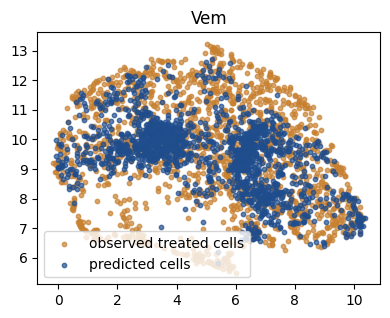

In [9]:
drug = "Vem"
X_pre_replicate_1, X_post_replicate_1 = prepare_pair_from_mat('COLO858', 'DMSO','24h', drug, '72h', 1)
X_pre_replicate_2, X_post_replicate_2 = prepare_pair_from_mat('COLO858', 'DMSO','24h', drug, '72h', 2) 

jfe_indices = [1, 6, 0, 5, 4, 7, 8, 2, 3, 19]  


X_tr_pre = X_pre_replicate_1
Y_tr_post = X_post_replicate_1
X_te_pre = X_pre_replicate_2
Y_te_post = X_post_replicate_2

print(X_tr_pre.shape)
print(X_te_pre.shape)
print(Y_tr_post.shape)
print(Y_te_post.shape)

# Compute median heuristic gamma on training data
median_gamma = median_heuristic_gamma(X_tr_pre, Y_tr_post)
print("Median heuristic gamma:", median_gamma)


all_metrics = []
for run in range(10):
    print(f"**************** Run: {run} ****************")
    seed = 1234 + run
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    out = run_cellot_pair(X_tr_pre[:, jfe_indices], Y_tr_post[:, jfe_indices], X_te_pre[:, jfe_indices], Y_te_post[:, jfe_indices], n_epochs=2000)
    metrics = summarize_metrics(out["y_pred"], Y_te_post[:, jfe_indices], median_gamma)
    print(f"Run {run} metrics: {metrics}")
    all_metrics.append(metrics)

# Results summary
df = pd.DataFrame(all_metrics)
print(df.describe().T[['mean', 'std']].round(4))


from umap import UMAP
import matplotlib.pyplot as plt

source = Y_tr_post[:, jfe_indices]
target = Y_te_post[:, jfe_indices]
predicted = out.get('y_pred') 

# Instantiate UMAP
umap_model = UMAP(n_components=2, random_state=42)

all_sample_umap = umap_model.fit_transform(np.vstack([source, target]))
source_umap = umap_model.transform(source)
target_umap = umap_model.transform(target)
y_pred_umap = umap_model.transform(predicted)

fig, ax = plt.subplots(figsize=(4, 4))
# ax.scatter(source_umap[:, 0], source_umap[:, 1], s=10, alpha=0.7, label='train_post', color='C2')
ax.scatter(target_umap[:, 0], target_umap[:, 1], s=10, alpha=0.7, label='observed treated cells', color="#C88131")
ax.scatter(y_pred_umap[:, 0], y_pred_umap[:, 1], s=10, alpha=0.7, label='predicted cells', color="#1F4D8D")

ax.set_title(f'{drug}')
# ax.set_xlabel('UMAP 1')
# ax.set_ylabel('UMAP 2')
ax.set_aspect('equal', 'box')
# Add a legend to distinguish the points
ax.legend()
# Adjust layout
plt.tight_layout()
# Display the plot
plt.savefig(f"./plots/cellot_on_4i_drug_{drug}.png", dpi=300)

Cell line:  WM902B
['DMSO' 'Vem' 'Vem+Tram']
Cell line:  WM902B
['DMSO' 'Vem' 'Vem+Tram']
(2837, 20)
(2713, 20)
(2837, 20)
(2713, 20)


VERS torch=1.13.1+cu117 (CellOT), device=cuda


Median heuristic gamma: 0.06602327475443821
**************** Run: 0 ****************


[CellOT] epoch=0 f_loss=-1.2204 g_loss=-4.4333 | train mmd=0.4089 | test_mmd=1.3516
[CellOT] epoch=50 f_loss=-1.7853 g_loss=0.3539 | train mmd=0.5397 | test_mmd=0.2644
[CellOT] epoch=100 f_loss=-2.4574 g_loss=2.4039 | train mmd=0.6695 | test_mmd=0.2111
[CellOT] epoch=150 f_loss=-4.1711 g_loss=4.5755 | train mmd=0.6609 | test_mmd=0.1758
[CellOT] epoch=200 f_loss=-5.8823 g_loss=6.7021 | train mmd=0.6505 | test_mmd=0.1475
[CellOT] epoch=250 f_loss=-6.4639 g_loss=7.5506 | train mmd=0.5961 | test_mmd=0.1155
[CellOT] epoch=300 f_loss=-7.6087 g_loss=9.7667 | train mmd=0.5721 | test_mmd=0.0943
[CellOT] epoch=350 f_loss=-8.3212 g_loss=11.5339 | train mmd=0.5313 | test_mmd=0.0754
[CellOT] epoch=400 f_loss=-9.1381 g_loss=13.4281 | train mmd=0.4857 | test_mmd=0.0583
[CellOT] epoch=450 f_loss=-9.2307 g_loss=13.8366 | train mmd=0.4519 | test_mmd=0.0449
[CellOT] epoch=500 f_loss=-8.6409 g_loss=14.6809 | train mmd=0.4070 | test_mmd=0.0334
[CellOT] epoch=550 f_loss=-8.8575 g_loss=14.2729 | train mmd=0.

Run 0 metrics: {'mmd2_gamma_median': 0.010743827417293517, 'mmd2_gamma_0.5': 0.019624868032328213, 'mmd2_gamma_1.0': 0.018003721052558874, 'wasserstein_distance': 0.8217104969859785, 'R2_feature_means': 0.9772567256356518}
**************** Run: 1 ****************


...

[CellOT] epoch=0 f_loss=1.4717 g_loss=-4.5110 | train mmd=0.4209 | test_mmd=1.1142
[CellOT] epoch=50 f_loss=-2.3304 g_loss=0.1648 | train mmd=0.4527 | test_mmd=0.2350
[CellOT] epoch=100 f_loss=-3.1462 g_loss=2.7470 | train mmd=0.6884 | test_mmd=0.2145
[CellOT] epoch=150 f_loss=-4.5648 g_loss=5.2703 | train mmd=0.6955 | test_mmd=0.1855
[CellOT] epoch=200 f_loss=-6.4245 g_loss=7.6053 | train mmd=0.6795 | test_mmd=0.1563
[CellOT] epoch=250 f_loss=-8.2025 g_loss=9.5780 | train mmd=0.6271 | test_mmd=0.1220
[CellOT] epoch=300 f_loss=-8.7721 g_loss=10.4857 | train mmd=0.5849 | test_mmd=0.0972
[CellOT] epoch=350 f_loss=-9.5237 g_loss=12.3997 | train mmd=0.5490 | test_mmd=0.0770
[CellOT] epoch=400 f_loss=-10.6150 g_loss=14.2019 | train mmd=0.5271 | test_mmd=0.0623
[CellOT] epoch=450 f_loss=-9.6510 g_loss=15.6628 | train mmd=0.4806 | test_mmd=0.0477
[CellOT] epoch=500 f_loss=-11.2452 g_loss=17.6924 | train mmd=0.4264 | test_mmd=0.0357
[CellOT] epoch=550 f_loss=-10.2205 g_loss=17.3928 | train mmd

Run 8 metrics: {'mmd2_gamma_median': 0.010895512684885311, 'mmd2_gamma_0.5': 0.025024603387669653, 'mmd2_gamma_1.0': 0.02279880114705396, 'wasserstein_distance': 0.8378774633843065, 'R2_feature_means': 0.9808215457439904}
**************** Run: 9 ****************


[CellOT] epoch=0 f_loss=-0.8976 g_loss=-6.2964 | train mmd=0.3840 | test_mmd=1.4560
[CellOT] epoch=50 f_loss=-1.8160 g_loss=0.0970 | train mmd=0.6230 | test_mmd=0.2620
[CellOT] epoch=100 f_loss=-3.0547 g_loss=2.2769 | train mmd=0.6874 | test_mmd=0.2207
[CellOT] epoch=150 f_loss=-4.5704 g_loss=4.8700 | train mmd=0.6960 | test_mmd=0.1951
[CellOT] epoch=200 f_loss=-5.4969 g_loss=7.0988 | train mmd=0.6588 | test_mmd=0.1532
[CellOT] epoch=250 f_loss=-7.2012 g_loss=8.0849 | train mmd=0.6021 | test_mmd=0.1225
[CellOT] epoch=300 f_loss=-8.4961 g_loss=9.8627 | train mmd=0.5796 | test_mmd=0.1024
[CellOT] epoch=350 f_loss=-9.4407 g_loss=10.4042 | train mmd=0.5423 | test_mmd=0.0815
[CellOT] epoch=400 f_loss=-9.3840 g_loss=12.6060 | train mmd=0.4930 | test_mmd=0.0619
[CellOT] epoch=450 f_loss=-10.5341 g_loss=14.0882 | train mmd=0.4369 | test_mmd=0.0502
[CellOT] epoch=500 f_loss=-10.1167 g_loss=14.6176 | train mmd=0.3912 | test_mmd=0.0360
[CellOT] epoch=550 f_loss=-9.4337 g_loss=15.7562 | train mmd=

Run 9 metrics: {'mmd2_gamma_median': 0.007403159087441935, 'mmd2_gamma_0.5': 0.021735806055422024, 'mmd2_gamma_1.0': 0.021429519448054768, 'wasserstein_distance': 0.9262557331337556, 'R2_feature_means': 0.9889823403940448}
                        mean     std
mmd2_gamma_median     0.0095  0.0022
mmd2_gamma_0.5        0.0201  0.0029
mmd2_gamma_1.0        0.0189  0.0026
wasserstein_distance  0.9238  0.1775
R2_feature_means      0.9803  0.0071


/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


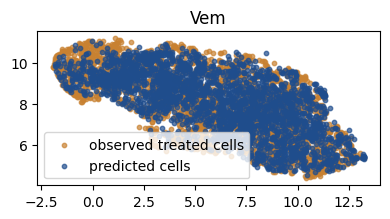

In [10]:
drug = "Vem"
X_pre_replicate_1, X_post_replicate_1 = prepare_pair_from_mat('WM902B', 'DMSO','24h', drug, '72h', 1)
X_pre_replicate_2, X_post_replicate_2 = prepare_pair_from_mat('WM902B', 'DMSO','24h', drug, '72h', 2) 

jfe_indices = [1, 6, 0, 5, 4, 7, 8, 2, 3, 19]  


X_tr_pre = X_pre_replicate_1
Y_tr_post = X_post_replicate_1
X_te_pre = X_pre_replicate_2
Y_te_post = X_post_replicate_2

print(X_tr_pre.shape)
print(X_te_pre.shape)
print(Y_tr_post.shape)
print(Y_te_post.shape)

# Compute median heuristic gamma on training data
median_gamma = median_heuristic_gamma(X_tr_pre, Y_tr_post)
print("Median heuristic gamma:", median_gamma)


all_metrics = []
for run in range(10):
    print(f"**************** Run: {run} ****************")
    seed = 1234 + run
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    out = run_cellot_pair(X_tr_pre[:, jfe_indices], Y_tr_post[:, jfe_indices], X_te_pre[:, jfe_indices], Y_te_post[:, jfe_indices], n_epochs=2000)
    metrics = summarize_metrics(out["y_pred"], Y_te_post[:, jfe_indices], median_gamma)
    print(f"Run {run} metrics: {metrics}")
    all_metrics.append(metrics)

# Results summary
df = pd.DataFrame(all_metrics)
print(df.describe().T[['mean', 'std']].round(4))


from umap import UMAP
import matplotlib.pyplot as plt

source = Y_tr_post[:, jfe_indices]
target = Y_te_post[:, jfe_indices]
predicted = out.get('y_pred') 

# Instantiate UMAP
umap_model = UMAP(n_components=2, random_state=42)

all_sample_umap = umap_model.fit_transform(np.vstack([source, target]))
source_umap = umap_model.transform(source)
target_umap = umap_model.transform(target)
y_pred_umap = umap_model.transform(predicted)

fig, ax = plt.subplots(figsize=(4, 4))
# ax.scatter(source_umap[:, 0], source_umap[:, 1], s=10, alpha=0.7, label='train_post', color='C2')
ax.scatter(target_umap[:, 0], target_umap[:, 1], s=10, alpha=0.7, label='observed treated cells', color="#C88131")
ax.scatter(y_pred_umap[:, 0], y_pred_umap[:, 1], s=10, alpha=0.7, label='predicted cells', color="#1F4D8D")

ax.set_title(f'{drug}')
# ax.set_xlabel('UMAP 1')
# ax.set_ylabel('UMAP 2')
ax.set_aspect('equal', 'box')
# Add a legend to distinguish the points
ax.legend()
# Adjust layout
plt.tight_layout()
# Display the plot
plt.savefig(f"./plots/cellot_on_4i_drug_{drug}.png", dpi=300)

Cell line:  SKMEL19
['DMSO' 'Vem' 'Vem+Tram']
Cell line:  SKMEL19
['DMSO' 'Vem' 'Vem+Tram']


VERS torch=1.13.1+cu117 (CellOT), device=cuda


(1514, 20)
(1163, 20)
(1514, 20)
(1163, 20)
Median heuristic gamma: 0.10646172143931386
**************** Run: 0 ****************


[CellOT] epoch=0 f_loss=-0.1288 g_loss=-4.6910 | train mmd=0.3141 | test_mmd=0.8676
[CellOT] epoch=50 f_loss=-2.5526 g_loss=-1.6935 | train mmd=0.1034 | test_mmd=0.0861
[CellOT] epoch=100 f_loss=-0.9097 g_loss=-0.7224 | train mmd=0.1247 | test_mmd=0.0291
[CellOT] epoch=150 f_loss=-0.8934 g_loss=0.5856 | train mmd=0.1036 | test_mmd=0.0164
[CellOT] epoch=200 f_loss=-0.9848 g_loss=2.0051 | train mmd=0.0801 | test_mmd=0.0130
[CellOT] epoch=250 f_loss=-0.7718 g_loss=1.9986 | train mmd=0.0706 | test_mmd=0.0103
[CellOT] epoch=300 f_loss=-0.0440 g_loss=2.0497 | train mmd=0.0649 | test_mmd=0.0073
[CellOT] epoch=350 f_loss=-0.4820 g_loss=2.5921 | train mmd=0.0500 | test_mmd=0.0059
[CellOT] epoch=400 f_loss=-0.4879 g_loss=2.8285 | train mmd=0.0478 | test_mmd=0.0057
[CellOT] epoch=450 f_loss=-0.2042 g_loss=3.5881 | train mmd=0.0368 | test_mmd=0.0075
[CellOT] epoch=500 f_loss=0.1309 g_loss=2.8540 | train mmd=0.0269 | test_mmd=0.0072
[CellOT] epoch=550 f_loss=0.0302 g_loss=4.2940 | train mmd=0.0133 

Run 0 metrics: {'mmd2_gamma_median': 0.014379312181877157, 'mmd2_gamma_0.5': 0.025850529153371937, 'mmd2_gamma_1.0': 0.02316241446454717, 'wasserstein_distance': 0.6483409992457778, 'R2_feature_means': 0.9761351667751984}
**************** Run: 1 ****************


...

[CellOT] epoch=50 f_loss=-1.7561 g_loss=-1.3039 | train mmd=0.1132 | test_mmd=0.1005
[CellOT] epoch=100 f_loss=-0.2296 g_loss=-0.1264 | train mmd=0.1733 | test_mmd=0.0348
[CellOT] epoch=150 f_loss=-1.8582 g_loss=0.4353 | train mmd=0.1381 | test_mmd=0.0232
[CellOT] epoch=200 f_loss=-1.6027 g_loss=2.4064 | train mmd=0.1110 | test_mmd=0.0159
[CellOT] epoch=250 f_loss=-0.9850 g_loss=2.1118 | train mmd=0.0991 | test_mmd=0.0106
[CellOT] epoch=300 f_loss=-1.0084 g_loss=2.4533 | train mmd=0.0700 | test_mmd=0.0120
[CellOT] epoch=350 f_loss=-0.8753 g_loss=3.2567 | train mmd=0.0789 | test_mmd=0.0071
[CellOT] epoch=400 f_loss=-0.7588 g_loss=3.2495 | train mmd=0.0621 | test_mmd=0.0073
[CellOT] epoch=450 f_loss=-0.2266 g_loss=3.4936 | train mmd=0.0454 | test_mmd=0.0092
[CellOT] epoch=500 f_loss=-0.1430 g_loss=3.8233 | train mmd=0.0383 | test_mmd=0.0073
[CellOT] epoch=550 f_loss=0.0520 g_loss=4.2980 | train mmd=0.0214 | test_mmd=0.0109
[CellOT] epoch=600 f_loss=0.2774 g_loss=5.2509 | train mmd=0.0208

Run 8 metrics: {'mmd2_gamma_median': 0.00846164628520496, 'mmd2_gamma_0.5': 0.01680992720265373, 'mmd2_gamma_1.0': 0.016587371211605806, 'wasserstein_distance': 0.6166857496155, 'R2_feature_means': 0.9871851630201847}
**************** Run: 9 ****************


[CellOT] epoch=50 f_loss=-1.4919 g_loss=-1.5063 | train mmd=0.1268 | test_mmd=0.1072
[CellOT] epoch=100 f_loss=-0.6949 g_loss=-0.7158 | train mmd=0.0848 | test_mmd=0.0315
[CellOT] epoch=150 f_loss=-0.1203 g_loss=0.3644 | train mmd=0.0986 | test_mmd=0.0156
[CellOT] epoch=200 f_loss=-2.1778 g_loss=1.3392 | train mmd=0.0997 | test_mmd=0.0140
[CellOT] epoch=250 f_loss=-0.7971 g_loss=1.9096 | train mmd=0.0925 | test_mmd=0.0096
[CellOT] epoch=300 f_loss=-1.6236 g_loss=2.5775 | train mmd=0.0743 | test_mmd=0.0098
[CellOT] epoch=350 f_loss=-0.5056 g_loss=2.7110 | train mmd=0.0761 | test_mmd=0.0066
[CellOT] epoch=400 f_loss=-0.8241 g_loss=2.8641 | train mmd=0.0496 | test_mmd=0.0060
[CellOT] epoch=450 f_loss=0.0054 g_loss=3.2386 | train mmd=0.0363 | test_mmd=0.0098
[CellOT] epoch=500 f_loss=0.0296 g_loss=3.9032 | train mmd=0.0383 | test_mmd=0.0082
[CellOT] epoch=550 f_loss=0.3591 g_loss=4.3268 | train mmd=0.0193 | test_mmd=0.0111
[CellOT] epoch=600 f_loss=-0.6027 g_loss=6.0628 | train mmd=0.0183 

Run 9 metrics: {'mmd2_gamma_median': 0.01068705410312809, 'mmd2_gamma_0.5': 0.019104611629782053, 'mmd2_gamma_1.0': 0.017776651683633737, 'wasserstein_distance': 0.6362242126788694, 'R2_feature_means': 0.9830026969104776}
                        mean     std
mmd2_gamma_median     0.0097  0.0028
mmd2_gamma_0.5        0.0178  0.0044
mmd2_gamma_1.0        0.0168  0.0035
wasserstein_distance  0.6247  0.0178
R2_feature_means      0.9845  0.0050


/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


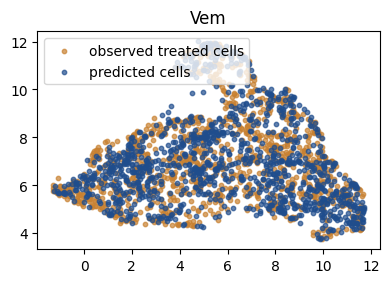

In [11]:
drug = "Vem"
X_pre_replicate_1, X_post_replicate_1 = prepare_pair_from_mat('SKMEL19', 'DMSO','24h', drug, '72h', 1)
X_pre_replicate_2, X_post_replicate_2 = prepare_pair_from_mat('SKMEL19', 'DMSO','24h', drug, '72h', 2) 

jfe_indices = [1, 6, 0, 5, 4, 7, 8, 2, 3, 19]  


X_tr_pre = X_pre_replicate_1
Y_tr_post = X_post_replicate_1
X_te_pre = X_pre_replicate_2
Y_te_post = X_post_replicate_2

print(X_tr_pre.shape)
print(X_te_pre.shape)
print(Y_tr_post.shape)
print(Y_te_post.shape)

# Compute median heuristic gamma on training data
median_gamma = median_heuristic_gamma(X_tr_pre, Y_tr_post)
print("Median heuristic gamma:", median_gamma)


all_metrics = []
for run in range(10):
    print(f"**************** Run: {run} ****************")
    seed = 1234 + run
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    out = run_cellot_pair(X_tr_pre[:, jfe_indices], Y_tr_post[:, jfe_indices], X_te_pre[:, jfe_indices], Y_te_post[:, jfe_indices], n_epochs=2000)
    metrics = summarize_metrics(out["y_pred"], Y_te_post[:, jfe_indices], median_gamma)
    print(f"Run {run} metrics: {metrics}")
    all_metrics.append(metrics)

# Results summary
df = pd.DataFrame(all_metrics)
print(df.describe().T[['mean', 'std']].round(4))


from umap import UMAP
import matplotlib.pyplot as plt

source = Y_tr_post[:, jfe_indices]
target = Y_te_post[:, jfe_indices]
predicted = out.get('y_pred') 

# Instantiate UMAP
umap_model = UMAP(n_components=2, random_state=42)

all_sample_umap = umap_model.fit_transform(np.vstack([source, target]))
source_umap = umap_model.transform(source)
target_umap = umap_model.transform(target)
y_pred_umap = umap_model.transform(predicted)

fig, ax = plt.subplots(figsize=(4, 4))
# ax.scatter(source_umap[:, 0], source_umap[:, 1], s=10, alpha=0.7, label='train_post', color='C2')
ax.scatter(target_umap[:, 0], target_umap[:, 1], s=10, alpha=0.7, label='observed treated cells', color="#C88131")
ax.scatter(y_pred_umap[:, 0], y_pred_umap[:, 1], s=10, alpha=0.7, label='predicted cells', color="#1F4D8D")

ax.set_title(f'{drug}')
# ax.set_xlabel('UMAP 1')
# ax.set_ylabel('UMAP 2')
ax.set_aspect('equal', 'box')
# Add a legend to distinguish the points
ax.legend()
# Adjust layout
plt.tight_layout()
# Display the plot
plt.savefig(f"./plots/cellot_on_4i_drug_{drug}.png", dpi=300)